Residence time retentate side: 42.676820868552866
Residence time permeate side: 0.08370022877294933
number of time steps: 20, number of iterations: 8, number of pressure iterations: 5  
number of solves for pressure: 945, number of solves for concentration: 190


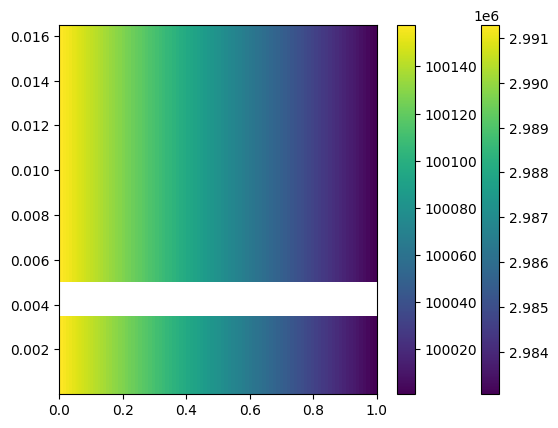

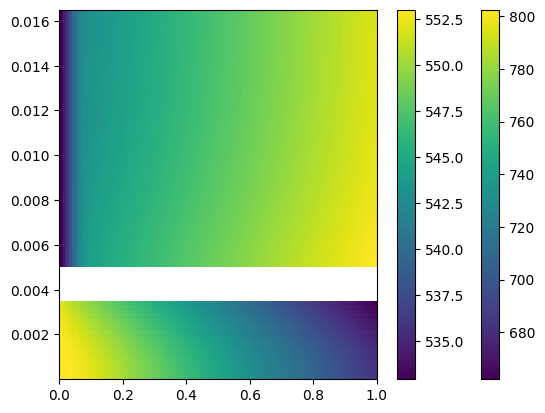

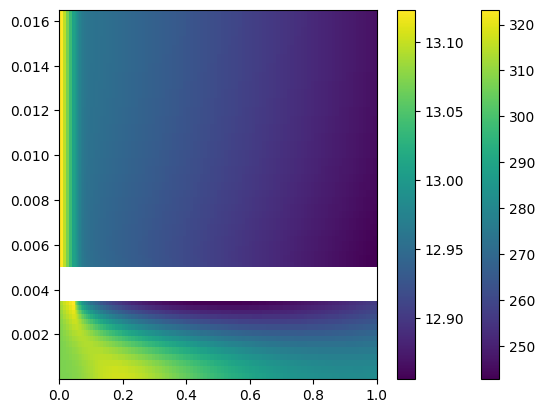

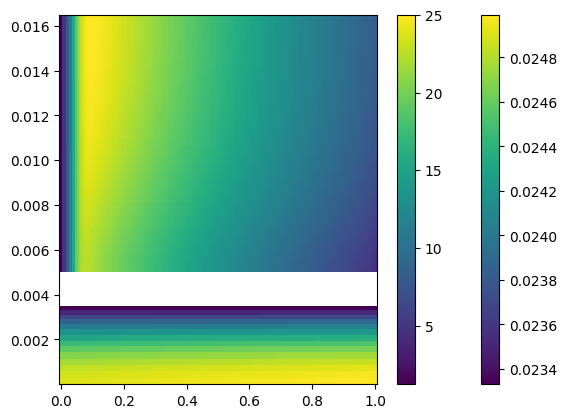

[[0.006      0.004      0.        ]
 [0.00453218 0.00358924 0.00019238]]
[[0.006      0.004      0.        ]
 [0.00626611 0.0040102  0.00060878]]
total balance per component: [ 0.00120171  0.00040056 -0.00080116]
elemental H balance: -5.286660852187389e-08
elemental N balance: -4.0133370740320744e-08


In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import importlib
import membrane_reactor
importlib.reload(membrane_reactor)
from membrane_reactor import MembraneReactor

#import warnings
#warnings.simplefilter("error")

F = 1e-2 # moles per second, 2e-4 mol/s
membrane_reactor = MembraneReactor('input.json', F_ret_in = F, F_perm_in = F, is_counter_current=False, num_pressure_iterations=5, num_newton_iterations=10, dt = 5e0, num_timesteps = 20, rtol_dc = 1e-6, rtol = 1e-4, atol_p = 1.0)
membrane_reactor.info()
    
p = membrane_reactor.p
p_vect = p.ravel()
p_perm = p[:, :membrane_reactor.num_r_perm]
p_ret = p[:, membrane_reactor.num_r_perm:]


i, j, k, cnt_p, cnt_c= membrane_reactor.solve()
print(f'number of time steps: {i}, number of iterations: {j}, number of pressure iterations: {k}  ')
print(f'number of solves for pressure: {cnt_p}, number of solves for concentration: {cnt_c}')
#g, jac =membrane_reactor.solve2()

#plt.plot(membrane_reactor.z_c[:], g[:, 0, 0])
#plt.show()

p_min = np.min(p)
p_max = np.max(p)
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, p_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, p_perm[:, :].T)
plt.colorbar()
plt.show()

#plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, membrane_reactor.div_u[:, membrane_reactor.num_r_perm:].T)
#plt.colorbar()
#plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, membrane_reactor.div_u[:, :membrane_reactor.num_r_perm].T)
#plt.colorbar()
#plt.show()

T_perm = membrane_reactor.T[:, :membrane_reactor.num_r_perm]
T_ret = membrane_reactor.T[:, membrane_reactor.num_r_perm:]
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, T_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, T_perm[:, :].T)
plt.colorbar()
plt.show()

c_perm = membrane_reactor.c[:, :membrane_reactor.num_r_perm,:]
c_ret = membrane_reactor.c[:, membrane_reactor.num_r_perm:,:]
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, c_ret[:, :, 2].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, c_perm[:, :, 2].T)
plt.colorbar()
plt.show()

plt.pcolormesh(membrane_reactor.z_f, membrane_reactor.r_c_ret, membrane_reactor.u_ret_ax.T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_f, membrane_reactor.r_c_perm, membrane_reactor.u_perm_ax.T)
plt.colorbar()
plt.show()
#plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:, 10], '.')
#plt.show()

flows_ret_ax, flows_ret_rad, flows_perm_ax, flows_perm_rad = membrane_reactor.compute_flows()

print(flows_ret_ax[[0,-1],:])
#print(flows_ret_rad[[0,-1],:])
print(flows_perm_ax[[0,-1],:])
#print(flows_perm_rad[[0,-1],:])
flows_tot = flows_ret_ax[0,:] + flows_perm_ax[0,:] -  flows_ret_ax[-1,:] - flows_perm_ax[-1,:]
print(f'total balance per component: {flows_tot}')
print(f'elemental H balance: {2*flows_tot[0] + 3*flows_tot[2]}')
print(f'elemental N balance: {2*flows_tot[1] + flows_tot[2]}')


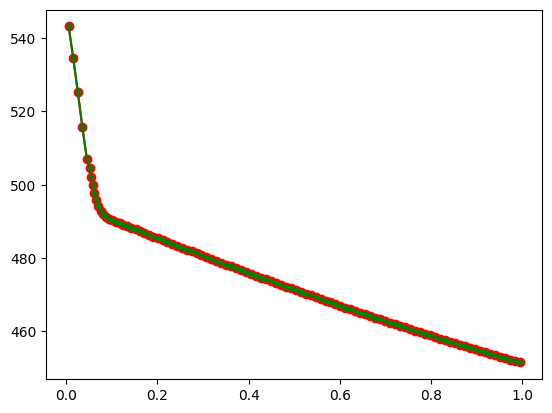

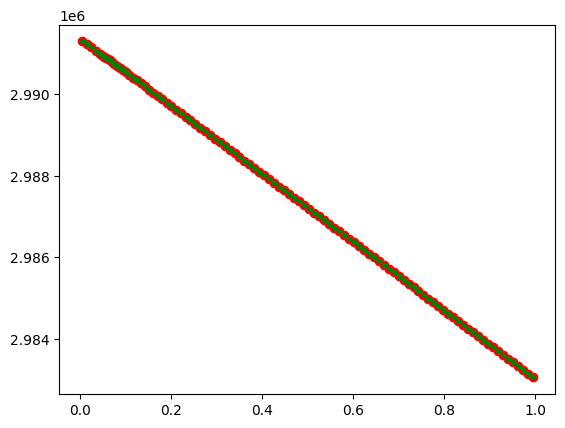

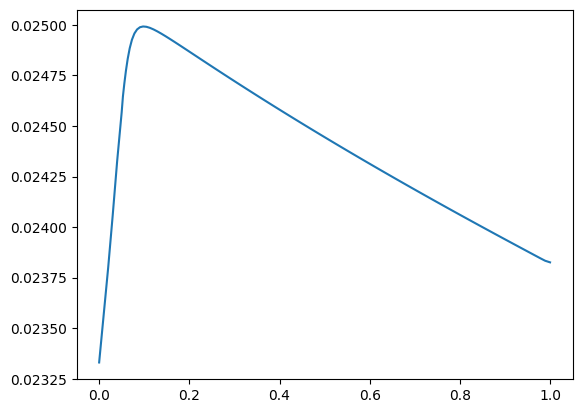

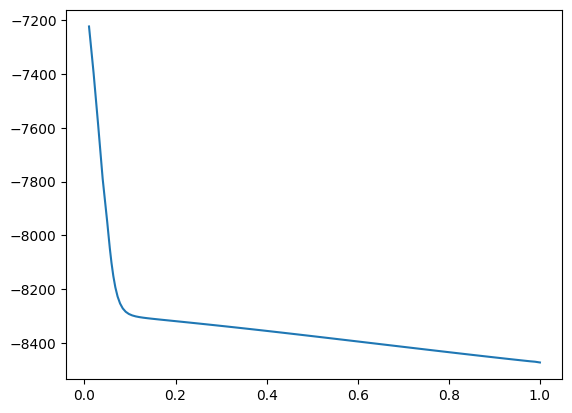

In [ ]:
from scipy import constants
c_tot = np.sum(membrane_reactor.c,axis=-1)
y = membrane_reactor.c / c_tot[..., np.newaxis]
c_tot_p = membrane_reactor.correlation.molar_density(y, membrane_reactor.T, membrane_reactor.p)

plt.plot(membrane_reactor.z_c, c_tot[:,-1], 'o-r')
plt.plot(membrane_reactor.z_c, c_tot_p[:, -1], '.-g')
plt.show()

#plt.plot(membrane_reactor.z_c, c_tot[:,0], 'o-r')
#plt.plot(membrane_reactor.z_c, c_tot_p[:,0], '.-g')
#plt.show()

p_ig = c_tot_p * constants.R * membrane_reactor.T
plt.plot(membrane_reactor.z_c, p_ig[:,-1], 'o-r')
plt.plot(membrane_reactor.z_c, membrane_reactor.p[:, -1], '.-g')
plt.show()


plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:,-1], '-')
plt.show()

grad_p = membrane_reactor.grad_p_ret_ax @ membrane_reactor.p.reshape((-1,1)) + membrane_reactor.grad_bc_p_ret_ax
grad_p = grad_p.reshape((membrane_reactor.num_z+1,-1))
plt.plot(membrane_reactor.z_f[1:], grad_p[1:,-1], '-')
plt.show()